🚀 HMUDF SIMULATION – Hybrid Multi-Agent System

📍 Drone 1: Planning optimal energy path to (13, 13)...
✔ Drone 1: Route ready (27 steps) | Energy used 38.0%
📍 Drone 2: Planning optimal energy path to (2, 12)...
✔ Drone 2: Route ready (14 steps) | Energy used 19.0%
📍 Drone 3: Planning optimal energy path to (12, 2)...
✔ Drone 3: Route ready (13 steps) | Energy used 17.5%
📦 Drone 1 delivered package at (13, 13)
📦 Drone 2 delivered package at (2, 12)
📦 Drone 3 delivered package at (12, 2)

🌩️ Extreme weather impacts Drone 1!
⚠️ Drone 1: High wind detected. Switching to safe hover.

🔁 AUCTION STARTED – Reassigning task (13, 13) from Drone 1
📨 Drone 2 bid: 25.70
📨 Drone 3 bid: 25.70
🎉 Drone 2 wins the auction!
📍 Drone 2: Planning optimal energy path to (13, 13)...
✔ Drone 2: Route ready (13 steps) | Energy used 22.1%

🏁 SIMULATION COMPLETED

Drone 1 → Power left: 42.04% | Final location: (13, 13)
Drone 2 → Power left: 58.92% | Final location: (2, 12)
Drone 3 → Power left: 82.48% | Final loc

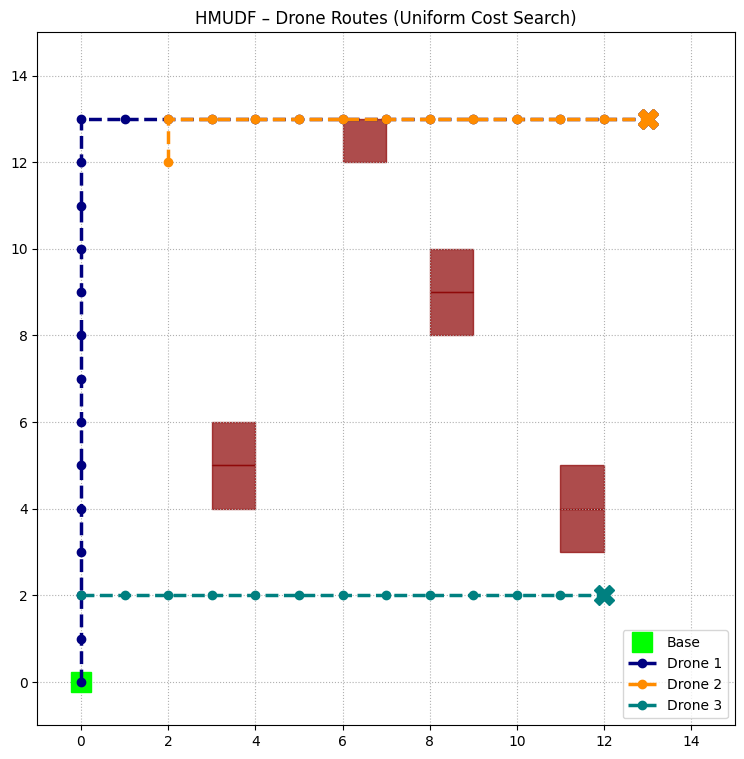

In [2]:
# HMUDF - Hybrid Multi-Drone Urban Delivery Framework Simulation
# Final Fixed Version: Uniform Cost Search + Auction + Live Plot
# Run in Google Colab / Jupyter Notebook

import matplotlib.pyplot as plt
from queue import PriorityQueue
import random

# ====================== CITY GRID SETUP ======================
class CityMap:
    def __init__(self):
        self.size = 15
        self.obstacles = [(3,4),(3,5),(8,8),(8,9),(11,3),(11,4),(6,12)]
        self.base = (0, 0)
        self.drop_zones = [(13,13), (2,12), (12,2)]
    
    def valid_position(self, x, y):
        return 0 <= x < self.size and 0 <= y < self.size and (x,y) not in self.obstacles


# ====================== UNIFORM COST ENERGY PLANNER ======================
def find_low_energy_path(city, start, goal, wind=1.0, weight=1.0):
    pq = PriorityQueue()
    pq.put((0, start))
    
    visited = {}
    cost_map = {start: 0}
    
    while not pq.empty():
        current_cost, current = pq.get()
        
        if current == goal:
            # Rebuild path
            path = []
            while current:
                path.append(current)
                current = visited.get(current)
            return path[::-1], current_cost
        
        for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
            nxt = (current[0] + dx, current[1] + dy)
            
            if city.valid_position(*nxt):
                step_cost = 1 * (1 + wind * 0.35 + weight * 0.25)
                new_cost = current_cost + step_cost
                
                if nxt not in cost_map or new_cost < cost_map[nxt]:
                    cost_map[nxt] = new_cost
                    visited[nxt] = current
                    pq.put((new_cost, nxt))
    
    return None, float('inf')


# ====================== SMART DRONE AGENT ======================
class SmartDrone:
    def __init__(self, number, start):
        self.number = number
        self.loc = start
        self.power = 100.0
        self.route = []
        self.job = None
    
    # Reactive Layer
    def safety_check(self, city, wind_level):
        if wind_level > 13:
            print(f"⚠️ Drone {self.number}: High wind detected. Switching to safe hover.")
            self.power -= 6
        
        if (self.loc[0]+1, self.loc[1]) in city.obstacles:
            print(f"🚧 Drone {self.number}: Obstacle ahead. Emergency stop.")
    
    # Deliberative Layer
    def plan_route(self, city, target, wind, weight):
        print(f"📍 Drone {self.number}: Planning optimal energy path to {target}...")
        
        path, cost = find_low_energy_path(city, self.loc, target, wind, weight)
        
        if path:
            self.route = path
            self.power -= cost
            print(f"✔ Drone {self.number}: Route ready ({len(path)} steps) | Energy used {cost:.1f}%")
        else:
            print(f"✘ Drone {self.number}: No feasible route found.")
    
    # Social Layer (Auction Offer)
    def make_offer(self, city, task):
        path, cost = find_low_energy_path(city, self.loc, task, wind=1.0, weight=1.5)
        if not path:
            return float('inf')
        
        power_penalty = 20 if self.power < 35 else 5
        offer_score = cost + power_penalty
        
        print(f"📨 Drone {self.number} bid: {offer_score:.2f}")
        return offer_score


# ====================== AUCTION MECHANISM ======================
def run_auction(stuck_drone, task, fleet, city):
    print(f"\n🔁 AUCTION STARTED – Reassigning task {task} from Drone {stuck_drone.number}")
    
    offers = []
    for drone in fleet:
        if drone.number != stuck_drone.number:
            score = drone.make_offer(city, task)
            offers.append((drone, score))
    
    winner = min(offers, key=lambda x: x[1])[0]
    winner.job = task
    
    print(f"🎉 Drone {winner.number} wins the auction!")
    
    winner.plan_route(city, task, wind=random.uniform(0.7,1.4), weight=1.8)
    return winner


# ====================== SIMULATION ENGINE ======================
def start_simulation():
    print("🚀 HMUDF SIMULATION – Hybrid Multi-Agent System\n")
    
    city = CityMap()
    fleet = [
        SmartDrone(1, (0,0)),
        SmartDrone(2, (0,1)),
        SmartDrone(3, (0,2))
    ]
    
    tasks = city.drop_zones[:]
    
    # Initial assignment
    for i, drone in enumerate(fleet):
        drone.job = tasks[i]
        drone.plan_route(city, tasks[i], wind=0.6, weight=1.0)
        drone.safety_check(city, wind_level=7)
    
    # Delivery simulation
    for drone in fleet:
        if drone.route:
            drone.loc = drone.route[-1]
            print(f"📦 Drone {drone.number} delivered package at {drone.loc}")
    
    # Weather failure event
    print("\n🌩️ Extreme weather impacts Drone 1!")
    fleet[0].safety_check(city, wind_level=17)
    fleet[0].power -= 14
    
    # Reassignment
    run_auction(fleet[0], tasks[0], fleet, city)
    
    # Final Report
    print("\n🏁 SIMULATION COMPLETED\n")
    for drone in fleet:
        print(f"Drone {drone.number} → Power left: {drone.power:.2f}% | Final location: {drone.loc}")
    
    # ====================== VISUALIZATION ======================
    fig, ax = plt.subplots(figsize=(9,9))
    ax.set_xlim(-1, city.size)
    ax.set_ylim(-1, city.size)
    ax.set_title("HMUDF – Drone Routes (Uniform Cost Search)")
    
    # Obstacles
    for obs in city.obstacles:
        ax.add_patch(plt.Rectangle(obs, 1, 1, color='darkred', alpha=0.7))
    
    ax.plot(city.base[0], city.base[1], 's', color='lime', markersize=14, label='Base')
    
    colors = ['navy', 'darkorange', 'teal']
    for idx, drone in enumerate(fleet):
        if drone.route:
            xs = [p[0] for p in drone.route]
            ys = [p[1] for p in drone.route]
            ax.plot(xs, ys, 'o--', color=colors[idx], linewidth=2.5, label=f'Drone {drone.number}')
            ax.plot(xs[-1], ys[-1], 'X', color=colors[idx], markersize=14)
    
    ax.legend()
    ax.grid(True, linestyle=':')
    plt.show()


# ====================== EXECUTION ======================
if __name__ == "__main__":
    start_simulation()